In [ ]:
# conda activate anndata

import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import tqdm as notebook_tqdm
from IPython.display import Image, display

os.chdir("scRNA-seq")

In [ ]:
adata = ad.read_h5ad("data/scVI/matrix_scvi.h5ad")

/mnt/lareaulab/reliscu/anaconda3/envs/anndata/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


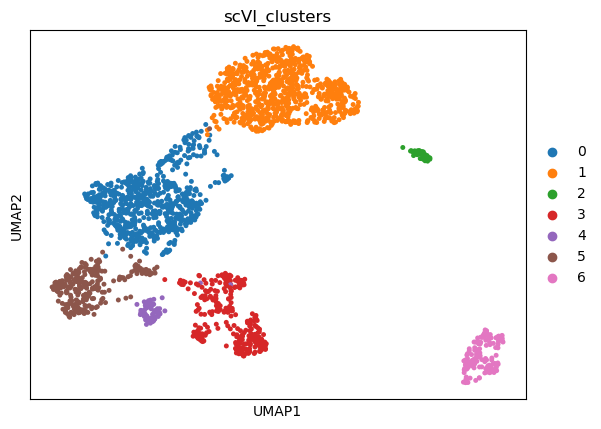

In [ ]:
sc.pp.neighbors(adata, use_rep="scVI")
sc.tl.umap(adata, min_dist=0.3)
sc.tl.leiden(adata, key_added="scVI_clusters", flavor="igraph", n_iterations=2, resolution=0.2)
sc.pl.umap(adata, color=['scVI_clusters'])

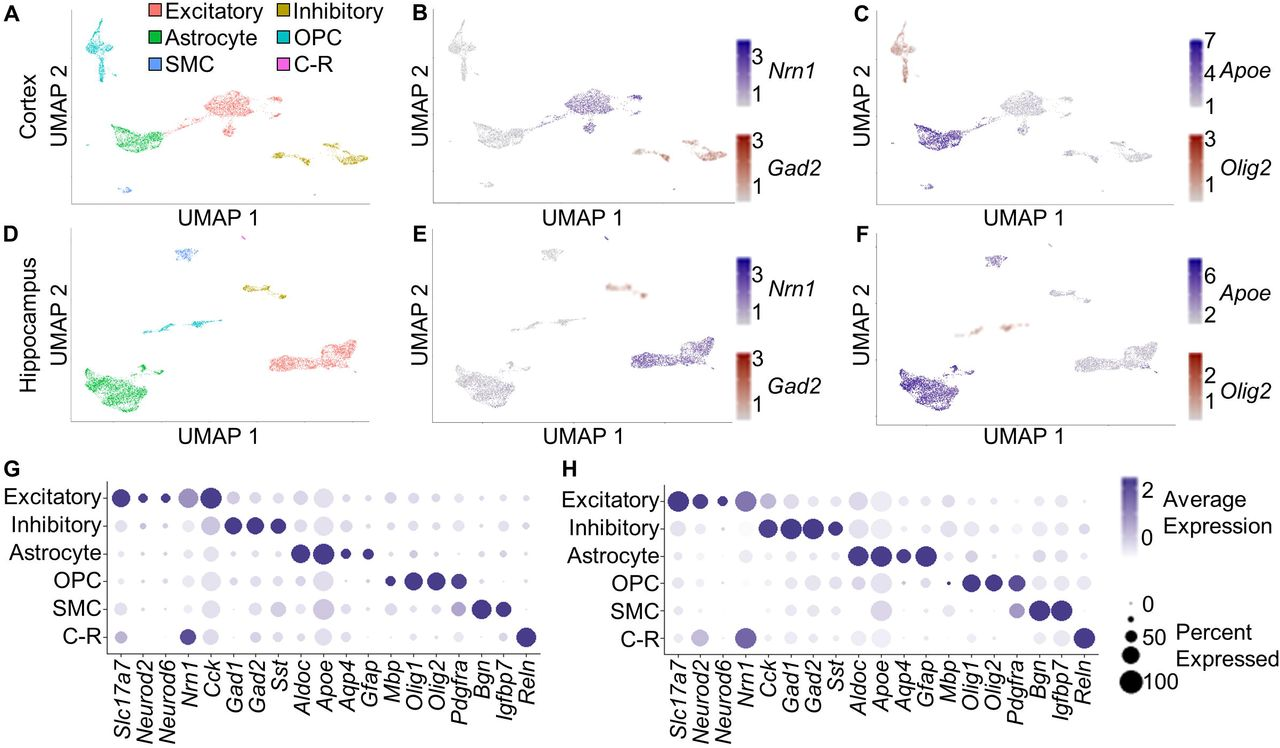

In [ ]:
# let's cross reference these clusters with marker gene expression (Fig. 2 from publication)

display(Image(filename="input_data/krizay_2022/F3.large.jpg"))

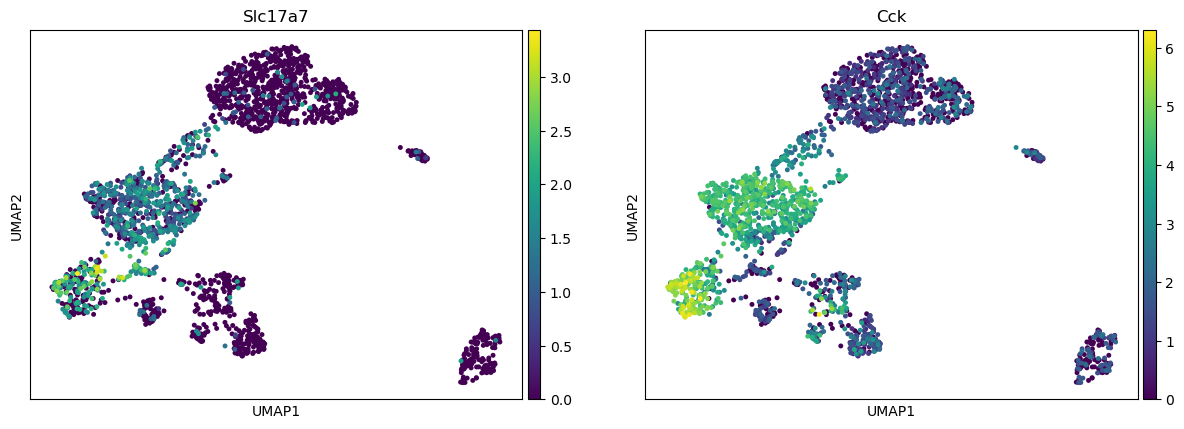

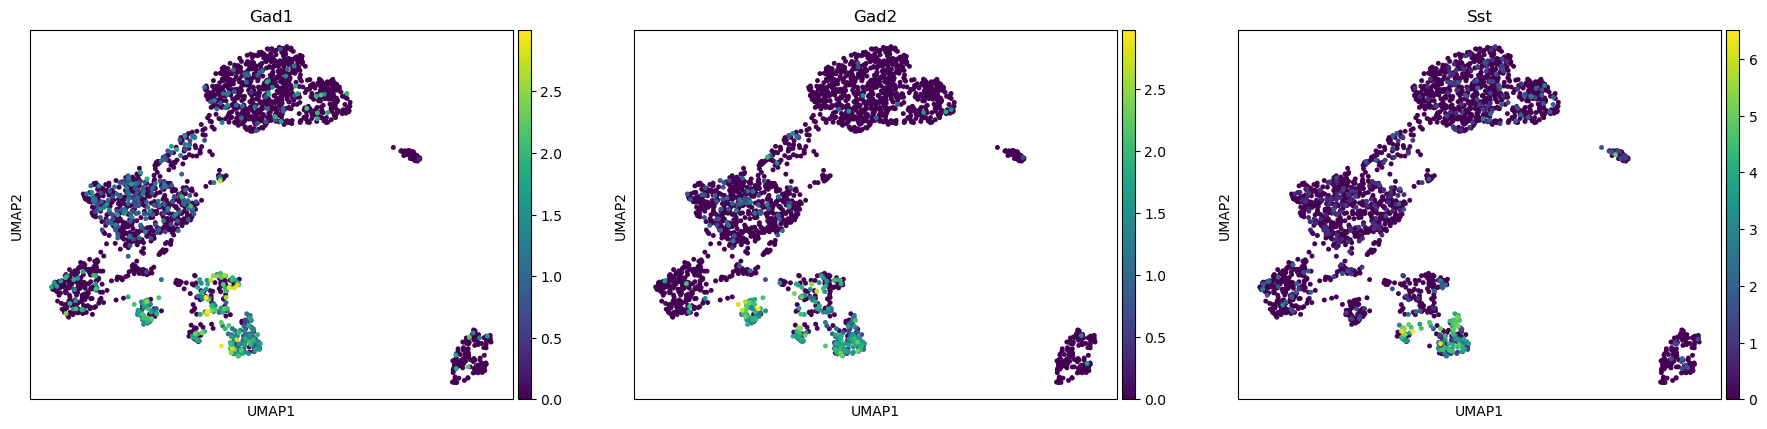

In [ ]:
# excitatory neurons

sc.pl.umap(adata, color=["Slc17a7", "Cck"], gene_symbols="gene_names")

# inhibitory neurons

sc.pl.umap(adata, color=["Gad1", "Gad2", "Sst"], gene_symbols="gene_names")

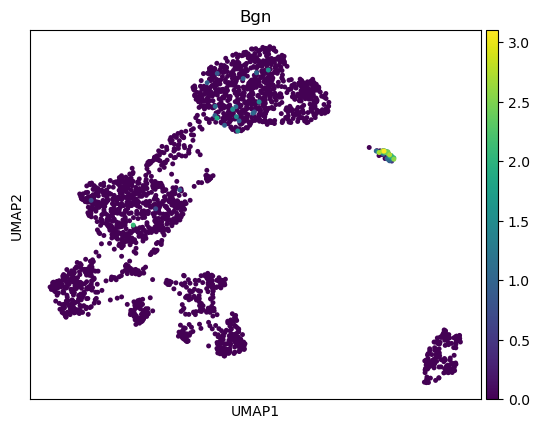

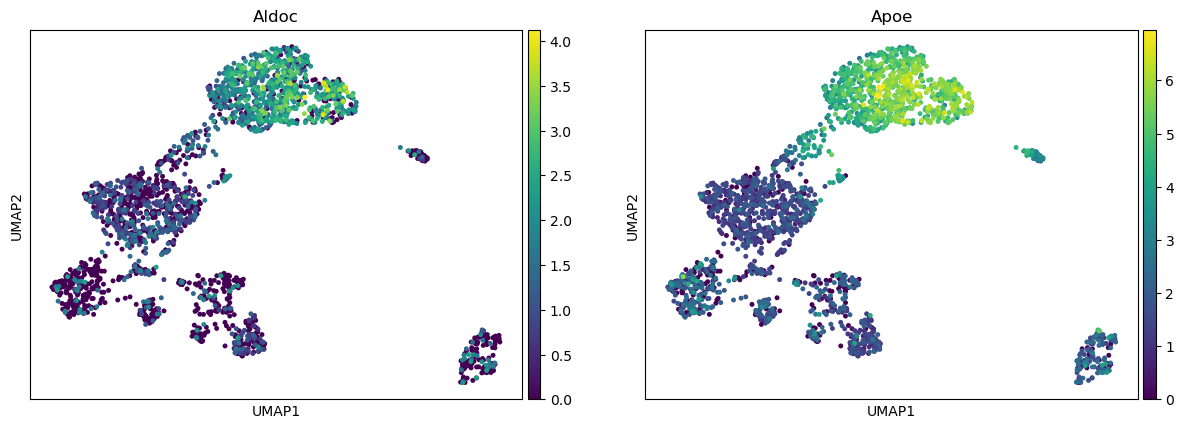

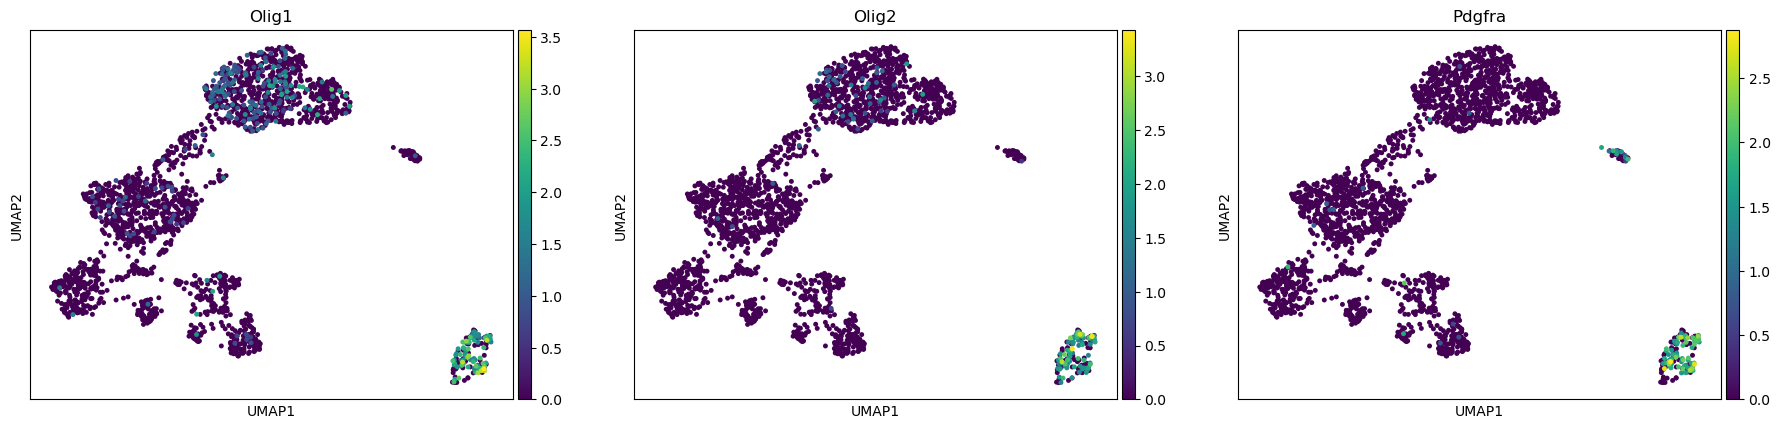

In [ ]:
# vascular cells

sc.pl.umap(adata, color=["Bgn"], gene_symbols="gene_names")

# astrocytes

sc.pl.umap(adata, color=["Aldoc", "Apoe"], gene_symbols="gene_names")

# OPCs

sc.pl.umap(adata, color=["Olig1", "Olig2", "Pdgfra"], gene_symbols="gene_names")

In [ ]:
# Annotate clusters

adata.obs['cell_type'] = None

adata.obs.loc[adata.obs['scVI_clusters'].astype("int").isin([0, 5]), 'cell_type'] = "Excitatory neuron"
adata.obs.loc[adata.obs['scVI_clusters'].astype("int").isin([3, 4]), 'cell_type'] = "Inhibitory neuron"
adata.obs.loc[adata.obs['scVI_clusters'].astype("int").isin([2]), 'cell_type'] = "SMC"
adata.obs.loc[adata.obs['scVI_clusters'].astype("int").isin([1]), 'cell_type'] = "Astrocyte"
adata.obs.loc[adata.obs['scVI_clusters'].astype("int").isin([6]), 'cell_type'] = "OPC"

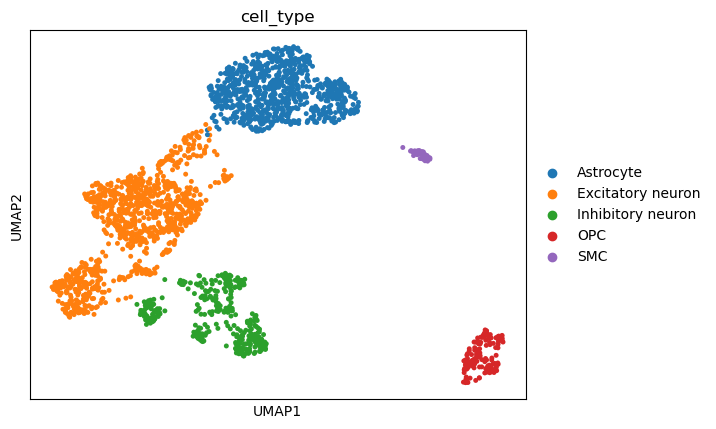

In [8]:
sc.pl.umap(adata, color=['cell_type'])

In [ ]:
# save 
adata.write("data/matrix_scvi_annotated.h5ad")